IMPORTS 

In [ ]:
import numpy as np
import pandas as pd
import os, math, time
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.linear_model   import LinearRegression, LogisticRegression
from sklearn.ensemble       import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics        import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print('Libraries loaded successfully.')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')


Libraries loaded successfully.
PyTorch version : 2.8.0+cpu
CUDA available  : False
Using device    : cpu


DATA LOADING

In [3]:
DATA_PATH = 'cleaned_taxi_data.parquet'

def load_data(path : str) -> pd.DataFrame:
    if path.endswith('.parquet'):
        return pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False)

df_raw = load_data(DATA_PATH)
print(f'Raw dataset shape : {df_raw.shape}')
print(f'Columns           : {df_raw.columns.tolist()}')

Raw dataset shape : (2241617, 19)
Columns           : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [4]:

df = df_raw[df_raw['payment_type'] == 1].copy()
print(f'After credit-card filter : {df.shape[0]:,} rows  ({df.shape[0]/df_raw.shape[0]:.1%} of original)')

for col in ['tpep_pickup_datetime', 'tpep_dropoff_datetime']:
    if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col])

df.head(3)

After credit-card filter : 2,241,617 rows  (100.0% of original)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
2,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0


In [5]:
ZONE_LOOKUP_PATH = 'taxi_zone_lookup.csv'

zone_df = pd.read_csv(ZONE_LOOKUP_PATH)
print(f'Zone lookup shape : {zone_df.shape}')
loc_to_borough = zone_df.set_index('LocationID')['Borough'].to_dict()
print('Zone lookup loaded. Sample:', dict(list(loc_to_borough.items())[:4]))


Zone lookup shape : (265, 4)
Zone lookup loaded. Sample: {1: 'EWR', 2: 'Queens', 3: 'Bronx', 4: 'Manhattan'}


FEATURE ENGINEERING

In [8]:
def engineer_features(df : pd.DataFrame, loc_to_borough : dict) -> pd.DataFrame:
    df = df.copy()

    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
    df['is_weekend'] = (df['pickup_day_of_week'] >= 5).astype(int)
  
    df['trip_duration_minutes'] = (
        (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    )

    df['trip_speed_mph'] = np.where(
        df['trip_duration_minutes'] > 0,
        (df['trip_distance'] / (df['trip_duration_minutes'] / 60)),
        np.nan 
    )

    df['log_trip_distance'] = np.log1p(df['trip_distance'])

    df['fare_per_mile'] = np.where(
        df['trip_distance'] > 0,
        df['fare_amount'] / df['trip_distance'],
        np.nan 
    )

    df['fare_per_minute'] = np.where(
        df['trip_duration_minutes'] > 0,
        df['fare_amount'] / df['trip_duration_minutes'],
        np.nan 
    )

    df['pickup_borough'] = df['PULocationID'].map(loc_to_borough).fillna('Unknown')
    df['dropoff_borough'] = df['DOLocationID'].map(loc_to_borough).fillna('Unknown')

    le = LabelEncoder()
    df['pickup_borough_enc'] = le.fit_transform(df['pickup_borough'])
    df['dropoff_borough_enc'] = le.fit_transform(df['dropoff_borough'])

    return df

df = engineer_features(df, loc_to_borough)
print('Feature engineering finished.')
print(df[['pickup_hour', 'pickup_day_of_week', 'is_weekend', 
          'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
          'fare_per_mile', 'fare_per_minute', 'pickup_borough', 'dropoff_borough']].describe().round(2)  )

Feature engineering finished.
       pickup_hour  pickup_day_of_week  is_weekend  trip_duration_minutes  \
count   2241617.00          2241617.00  2241617.00             2241617.00   
mean         14.37                2.88        0.26                  14.62   
std           5.67                1.93        0.44                  11.01   
min           0.00                0.00        0.00                   1.00   
25%          11.00                1.00        0.00                   7.27   
50%          15.00                3.00        0.00                  11.60   
75%          19.00                5.00        1.00                  18.43   
max          23.00                6.00        1.00                 294.00   

       trip_speed_mph  log_trip_distance  fare_per_mile  fare_per_minute  
count      2241617.00         2241617.00     2241617.00       2241617.00  
mean            11.51               1.17           7.85             1.27  
std             22.69               0.65          2

MAKING A TARGET VARIABLE CREATION

In [10]:
df['tip_amount'] = df['tip_amount']

df['high_tip'] = ((df['tip_amount'] > 0.20 * df['fare_amount']) & (df['fare_amount'] > 0)).astype(int)

print('Target variable distributions: ')
print(f'tip_amount - mean={df["tip_amount"].mean():.2f}, median={df["tip_amount"].median():.2f}, std={df["tip_amount"].std():.2f}')
print(f'high_tip   - 1 (high): mean={df["high_tip"].mean():.1%}, 0 (not high): mean={(1 - df["high_tip"].mean()):.1%}')

Target variable distributions: 
tip_amount - mean=4.20, median=3.16, std=3.84
high_tip   - 1 (high): mean=76.9%, 0 (not high): mean=23.1%


DATA SPLITTING

In [18]:
FEATURE_COLS = [
    'pickup_hour', 'pickup_day_of_week', 'is_weekend',
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'trip_distance', 'passenger_count',
    'fare_amount', 'fare_per_mile', 'fare_per_minute',
    'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge',
    'pickup_borough_enc', 'dropoff_borough_enc',
    'RatecodeID'
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

EXCLUDED = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'store_and_fwd_flag', 'payment_type',
    'tip_amount', 'high_tip', 'total_amount',
    'pickup_borough', 'dropoff_borough',
    'PULocationID', 'DOLocationID',
]

print ('Feature columns used: ')
for col in FEATURE_COLS:
    print(f' {col:20} dtype={df[col].dtype}')
print(f'\nExcluded columns: {EXCLUDED}')

Feature columns used: 
 pickup_hour          dtype=int32
 pickup_day_of_week   dtype=int32
 is_weekend           dtype=int64
 trip_duration_minutes dtype=float64
 trip_speed_mph       dtype=float64
 log_trip_distance    dtype=float64
 trip_distance        dtype=float64
 passenger_count      dtype=float64
 fare_amount          dtype=float64
 fare_per_mile        dtype=float64
 fare_per_minute      dtype=float64
 extra                dtype=float64
 mta_tax              dtype=float64
 tolls_amount         dtype=float64
 improvement_surcharge dtype=float64
 pickup_borough_enc   dtype=int64
 dropoff_borough_enc  dtype=int64
 RatecodeID           dtype=float64

Excluded columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'payment_type', 'tip_amount', 'high_tip', 'total_amount', 'pickup_borough', 'dropoff_borough', 'PULocationID', 'DOLocationID']


In [19]:
keep_cols = FEATURE_COLS + ['tip_amount', 'high_tip']
df_model = df[keep_cols].dropna()
print(f'Model dataset shape after dropping NA: {df_model.shape}')

X = df_model[FEATURE_COLS]
y_reg = df_model['tip_amount']
y_cls = df_model['high_tip']

X_tmp, X_test, y_reg_tmp, y_reg_test, y_cls_tmp, y_cls_test = train_test_split(
    X, y_reg, y_cls, 
    test_size=0.15, random_state=42, stratify=y_cls
)

val_fraction = 0.15 / (1 - 0.15)
X_train, X_val, y_reg_train, y_reg_val, y_cls_train, y_cls_val = train_test_split(
    X_tmp, y_reg_tmp, y_cls_tmp,
    test_size=val_fraction, random_state=42, stratify=y_cls_tmp
)

print(f'Train size      : {len(X_train):,}')
print(f'Validation size : {len(X_val):,}')
print(f'Test size       : {len(X_test):,}')

for name, yc in [('Train', y_cls_train), ('Val', y_cls_val), ('Test', y_cls_test)]:
    print(f'  high_tip in {name}: {yc.mean():.3%} positive')


Model dataset shape after dropping NA: (2241617, 20)
Train size      : 1,569,131
Validation size : 336,243
Test size       : 336,243
  high_tip in Train: 76.892% positive
  high_tip in Val: 76.892% positive
  high_tip in Test: 76.892% positive


STANDARD SCALER

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed, Feature means (train): ')
pd.Series(scaler.mean_, index=FEATURE_COLS).round(4)

Feature scaling completed, Feature means (train): 


pickup_hour              14.3673
pickup_day_of_week        2.8800
is_weekend                0.2558
trip_duration_minutes    14.6196
trip_speed_mph           11.5166
log_trip_distance         1.1655
trip_distance             3.2467
passenger_count           1.3454
fare_amount              18.1617
fare_per_mile             7.8514
fare_per_minute           1.2706
extra                     1.5787
mta_tax                   0.4971
tolls_amount              0.5550
improvement_surcharge     0.9999
pickup_borough_enc        3.0907
dropoff_borough_enc       2.9867
RatecodeID                1.0552
dtype: float64

PART 2: MODEL TRAINING AND TUNING

BASELINE MODELS
4 baseline models are trained: 
Regression - LinearRegression, RandomForestRegressor
Classification - LogisticRegression, RandomForestClassifier

In [23]:
def regression_metrics(y_true, t_pred, label= ''):
    mae = mean_absolute_error(y_true, t_pred)
    rmse = math.sqrt(mean_squared_error(y_true, t_pred))
    r2 = r2_score(y_true, t_pred)
    
    if label:
        print(f'{label} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}')
    return {'MAE' : mae, 'RMSE': rmse, 'R2': r2}

def classification_metrics(y_true, y_pred, y_prob=None, label=''):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    if label:
        print(f'{label:35s}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}

In [26]:
print('Regression Baselines')

lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_reg_train)
lr_reg_pred = lr_reg.predict(X_val_scaled)
metrics_lr_reg = regression_metrics(y_reg_val, lr_reg_pred, label='Linear Regression')

BASELINE_SAMPLE = 100_000
X_train_sample = X_train_scaled[:BASELINE_SAMPLE]
y_reg_train_sample = y_reg_train.iloc[:BASELINE_SAMPLE]

rf_reg = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_sample, y_reg_train_sample)
rf_reg_pred = rf_reg.predict(X_val_scaled)
metrics_rf_reg = regression_metrics(y_reg_val, rf_reg_pred, label='Random Forest Regressor')



Regression Baselines
Linear Regression - MAE: 1.21, RMSE: 2.37, R²: 0.6254
Random Forest Regressor - MAE: 1.21, RMSE: 2.39, R²: 0.6187


Used Sampling for RandomForest due to runtime constraints, about 100k rows

In [27]:
print('Classification Baselines')

lr_cls = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr_cls.fit(X_train_scaled, y_cls_train)
lr_cls_pred = lr_cls.predict(X_val_scaled)
lr_cls_prob = lr_cls.predict_proba(X_val_scaled)[:, 1]
metrics_lr_cls = classification_metrics(y_cls_val, lr_cls_pred, lr_cls_prob, label='Logistic Regression')

BASELINE_SAMPLE = 100_000
X_train_sample = X_train_scaled[:BASELINE_SAMPLE]
y_cls_train_sample = y_cls_train.iloc[:BASELINE_SAMPLE]

rf_cls = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_cls.fit(X_train_sample, y_cls_train_sample)
rf_cls_pred = rf_cls.predict(X_val_scaled)
rf_cls_prob = rf_cls.predict_proba(X_val_scaled)[:, 1]
metrics_rf_cls = classification_metrics(y_cls_val, rf_cls_pred, rf_cls_prob, label='Random Forest Classifier')

Classification Baselines
Logistic Regression                  Acc=0.7687  Prec=0.7694  Rec=0.9985  F1=0.8691  AUC=0.5867
Random Forest Classifier             Acc=0.7688  Prec=0.7695  Rec=0.9985  F1=0.8692  AUC=0.5933


HYPERPARAMETER TUNING

In [31]:
SAMPLE_SIZE = 50_000

if len(X_train_scaled) > SAMPLE_SIZE:
    _, X_tune, _, y_tune = train_test_split(
        X_train_scaled, y_cls_train,
        test_size=SAMPLE_SIZE, random_state=42, stratify=y_cls_train
    )
else:
    X_tune, y_tune = X_train_scaled, y_cls_train

print(f'Tuning sample size: {len(X_tune):,}')

param_dist = {
    'n_estimators': randint(50, 150),
    'max_depth': randint(5, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2'],
}

rscv = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,        # down from 20
    cv=3,             # down from 5 folds
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

t0 = time.time()
rscv.fit(X_tune, y_tune)
print(f'\nSearch completed in {time.time()-t0:.1f}s')
print(f'Best params : {rscv.best_params_}')
print(f'Best CV AUC : {rscv.best_score_:.4f}')

Tuning sample size: 50,000
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Search completed in 66.0s
Best params : {'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 137}
Best CV AUC : 0.5962


In [34]:
rf_cls_tuned = RandomForestClassifier(**rscv.best_params_, random_state=42, n_jobs=-1)
rf_cls_tuned.fit(X_train_sample, y_cls_train_sample)  

rf_cls_tuned_pred = rf_cls_tuned.predict(X_val_scaled)
rf_cls_tuned_prob = rf_cls_tuned.predict_proba(X_val_scaled)[:, 1]

print('\n Tuned vs Baseline Random Forest Classifier on Validation Set')
print('Baseline')
metrics_rf_cls_base = classification_metrics(y_cls_val, rf_cls_pred, rf_cls_prob, 'RF Baseline')
print('Tuned')
metrics_rf_cls_tuned = classification_metrics(y_cls_val, rf_cls_tuned_pred, rf_cls_tuned_prob, 'RF Tuned')


 Tuned vs Baseline Random Forest Classifier on Validation Set
Baseline
RF Baseline                          Acc=0.7688  Prec=0.7695  Rec=0.9985  F1=0.8692  AUC=0.5933
Tuned
RF Tuned                             Acc=0.7690  Prec=0.7692  Rec=0.9994  F1=0.8693  AUC=0.5943


NEURAL NETWORK 
for prediciting high_tip

In [38]:
class TipClassifierNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, x):
        return self.net(x).squeeze(1)
    
def make_dataloader(X_arr, y_arr, batch_size=2048, shuffle=True):
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    y_t = torch.tensor(y_arr.values, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle = shuffle)


BATCH_SIZE = 2048
EPOCHS = 20
LR = 1e-3

train_loader = make_dataloader(X_train_scaled, y_cls_train, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(X_val_scaled,   y_cls_val,   BATCH_SIZE, shuffle=False)

model     = TipClassifierNet(input_dim=X_train_scaled.shape[1]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

TipClassifierNet(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 46,849


In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        loss = criterion(model(X_batch), y_batch)
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    t_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    v_loss = evaluate_loss(model, val_loader, criterion, DEVICE)
    scheduler.step()
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    if epoch % 5 == 0 or epoch == 1:
       print(f'Epoch {epoch:3d}/{EPOCHS}  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}')

print('\nTraining complete.')

Epoch   1/20  train_loss=0.5344  val_loss=0.5310
Epoch   5/20  train_loss=0.5310  val_loss=0.5305
Epoch  10/20  train_loss=0.5308  val_loss=0.5307
Epoch  15/20  train_loss=0.5303  val_loss=0.5298
Epoch  20/20  train_loss=0.5302  val_loss=0.5297

Training complete.


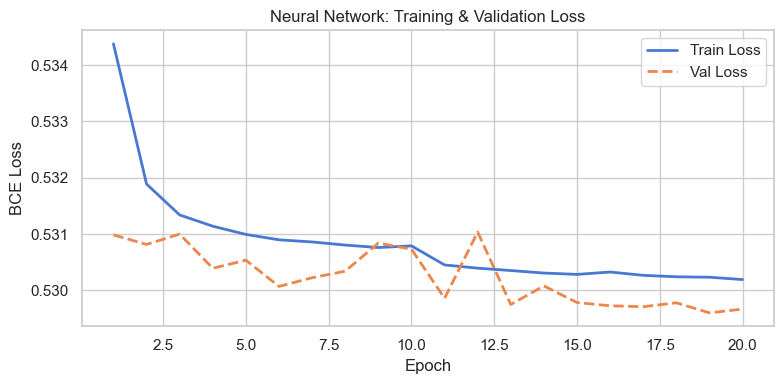

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', linewidth=2)
ax.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Neural Network: Training & Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
@torch.no_grad()
def get_predictions(model, X_arr, device, batch_size=2048):
    model.eval()
    logits_list = []
    X_t = torch.tensor(X_arr, dtype= torch.float32)
    for i in range(0, len(X_t), batch_size):
        batch = X_t[i:i+batch_size].to(device)
        logits_list.append(model(batch).cpu())
    logits = torch.cat(logits_list).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    return preds, probs

nn_val_pred, nn_val_prob = get_predictions(model, X_val_scaled, DEVICE)
print('=== Neural Network (Validation Set) ===')
metrics_nn = classification_metrics(y_cls_val, nn_val_pred, nn_val_prob, '  Neural Network')


=== Neural Network (Validation Set) ===
  Neural Network                     Acc=0.7691  Prec=0.7692  Rec=0.9996  F1=0.8694  AUC=0.5986
